<a href="https://colab.research.google.com/github/Merenguimona/act2_Adatos/blob/main/NOTEBOOKS/EDA_DENGUE_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalación de librerias

install.packages(c("janitor", "skimr"))
library(tidyverse)
library(janitor)
library(skimr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [2]:
# Carga de base de datos
dengue_data<- read.csv("https://raw.githubusercontent.com/Merenguimona/act2_Adatos/refs/heads/main/DB/Dengue_AM.csv")

In [3]:
# Normalizar los nombres con janitor y mostrarlos
dengue_data <- clean_names(dengue_data)
names(dengue_data)

[1] "id"                         "country_or_subregion"      
 [3] "serotype"                   "year"                      
 [5] "in_out_of_subregions"       "ew"                        
 [7] "country_sp"                 "iso3166"                   
 [9] "report"                     "type"                      
[11] "x_c_tc_x100_e"              "x_sd_d_x100_e"             
[13] "x0"                         "cfr_f"                     
[15] "confirmed"                  "deaths"                    
[17] "epidemiological_week_a"     "incidence_rate_c"          
[19] "lab_confirm_incidence_rate" "number_of_records"         
[21] "population_x_1000"          "severe_dengue_d"           
[23] "total_of_dengue_cases_b"

In [4]:
# Inspección inicial
glimpse(dengue_data)

Rows: 762
Columns: 23
$ id                         <int> 6, 6, 6, 6, 6, 6, 6, 5, 2, 2, 2, 3, 2, 6, 6…
$ country_or_subregion       <chr> "Grenada", "Anguilla", "Curaçao", "Jamaica"…
$ serotype                   <chr> "  ", "DEN 1", "  ", "DEN 2", "DEN 1,2", " …
$ year                       <int> 2025, 2019, 2024, 2024, 2024, 2017, 2017, 2…
$ in_out_of_subregions       <chr> "Out", "Out", "Out", "Out", "Out", "Out", "…
$ ew                         <int> 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53,…
$ country_sp                 <chr> "Granada", "Anguila", "Curazao", "Jamaica",…
$ iso3166                    <int> 308, 660, 531, 388, 28, 531, 388, 192, 340,…
$ report                     <chr> "01/01/2025", "01/01/2019", "01/01/2024", "…
$ type                       <chr> "Preliminar", "Preliminar", "Preliminar", "…
$ x_c_tc_x100_e              <dbl> 0.0000000, 33.3333333, 87.0229008, 2.114061…
$ x_sd_d_x100_e              <dbl> 2.30414746, 0.00000000, 0.00000000, 0.00000…
$ x0              

In [5]:
# Resumen general
summary(dengue_data)

       id        country_or_subregion      serotype        year     
 Min.   :1.000   Length   :762        Length   :762   Min.   :2014  
 1st Qu.:3.000   N.unique : 59        N.unique : 17   1st Qu.:2017  
 Median :6.000   N.blank  :  0        N.blank  :427   Median :2020  
 Mean   :4.567   Min.nchar:  4        Min.nchar:  2   Mean   :2020  
 3rd Qu.:6.000   Max.nchar: 34        Max.nchar: 11   3rd Qu.:2023  
 Max.   :7.000                                        Max.   :2026  
                                                                    
 in_out_of_subregions       ew         country_sp     iso3166     
 Length   :762        Min.   :53   Length   :762   Min.   : 28.0  
 N.unique :  2        1st Qu.:53   N.unique : 59   1st Qu.:170.0  
 N.blank  :  0        Median :53   N.blank  :  0   Median :388.0  
 Min.nchar:  2        Mean   :53   Min.nchar:  4   Mean   :408.4  
 Max.nchar:  3        3rd Qu.:53   Max.nchar: 30   3rd Qu.:652.0  
                      Max.   :53              

In [6]:
# Valores faltantes
colSums(is.na(dengue_data))

id       country_or_subregion 
                         0                          0 
                  serotype                       year 
                         0                          0 
      in_out_of_subregions                         ew 
                         0                          0 
                country_sp                    iso3166 
                         0                         91 
                    report                       type 
                         0                          0 
             x_c_tc_x100_e              x_sd_d_x100_e 
                       111                        115 
                        x0                      cfr_f 
                         0                        104 
                 confirmed                     deaths 
                        50                         43 
    epidemiological_week_a           incidence_rate_c 
                         0                          0 
lab_confirm_incidence_rate          number_of_records 
                         0                          0 
         population_x_1000            severe_dengue_d 
                         0                         54 
   total_of_dengue_cases_b 
                        36

In [8]:
#==========================
# PREPARACIÓN DEL DATASET
#==========================
# Número de registros antes de conversión
nrow(dengue_data)

[1] 762

In [10]:
# Conversión explícita a char antes de parse_number para modelo 2
# Se generaba un warning (no se observa warning en colab_SAL)
dengue_data <- dengue_data %>%
  mutate(
    across(
      c(incidence_rate_c, lab_confirm_incidence_rate),
      ~ parse_number(as.character(.))
    )
  ) %>%
  drop_na(deaths, incidence_rate_c)

In [11]:
# Número de registros después de conversión
nrow(dengue_data)

[1] 719

In [13]:
# Cuántos NA se generan
sum(is.na(dengue_data$incidence_rate_c))
mean(is.na(dengue_data$incidence_rate_c)) * 100

sum(is.na(dengue_data$lab_confirm_incidence_rate))
mean(is.na(dengue_data$lab_confirm_incidence_rate)) * 100

# Verificación
glimpse(dengue_data)

[1] 0

[1] 0

[1] 13

[1] 1.808067

Rows: 719
Columns: 23
$ id                         <int> 6, 6, 6, 6, 6, 6, 6, 5, 2, 2, 3, 2, 6, 6, 6…
$ country_or_subregion       <chr> "Grenada", "Anguilla", "Curaçao", "Jamaica"…
$ serotype                   <chr> "  ", "DEN 1", "  ", "DEN 2", "DEN 1,2", " …
$ year                       <int> 2025, 2019, 2024, 2024, 2024, 2017, 2017, 2…
$ in_out_of_subregions       <chr> "Out", "Out", "Out", "Out", "Out", "Out", "…
$ ew                         <int> 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53,…
$ country_sp                 <chr> "Granada", "Anguila", "Curazao", "Jamaica",…
$ iso3166                    <int> 308, 660, 531, 388, 28, 531, 388, 192, 340,…
$ report                     <chr> "01/01/2025", "01/01/2019", "01/01/2024", "…
$ type                       <chr> "Preliminar", "Preliminar", "Preliminar", "…
$ x_c_tc_x100_e              <dbl> 0.0000000, 33.3333333, 87.0229008, 2.114061…
$ x_sd_d_x100_e              <dbl> 2.30414746, 0.00000000, 0.00000000, 0.00000…
$ x0              

In [14]:
#==========================
# EDA GENERAL
#==========================

# Número de países
n_distinct(dengue_data$country_or_subregion)

[1] 59

In [15]:
# Rango temporal
range(dengue_data$year)

[1] 2014 2026

In [16]:
# Resumen numérico
summary(
  dengue_data %>%
    select(deaths, incidence_rate_c)
)

     deaths        incidence_rate_c  
 Min.   :   0.00   Min.   :    0.00  
 1st Qu.:   0.00   1st Qu.:   10.81  
 Median :   0.00   Median :   83.10  
 Mean   :  90.17   Mean   :  367.22  
 3rd Qu.:  10.00   3rd Qu.:  273.30  
 Max.   :8431.00   Max.   :16160.00  

In [18]:
#===============
# DISTRIBUCIÓN Y ASIMETRÍA
#===============
# Limpieza
dengue_data <- dengue_data %>%
  filter(is.finite(deaths))

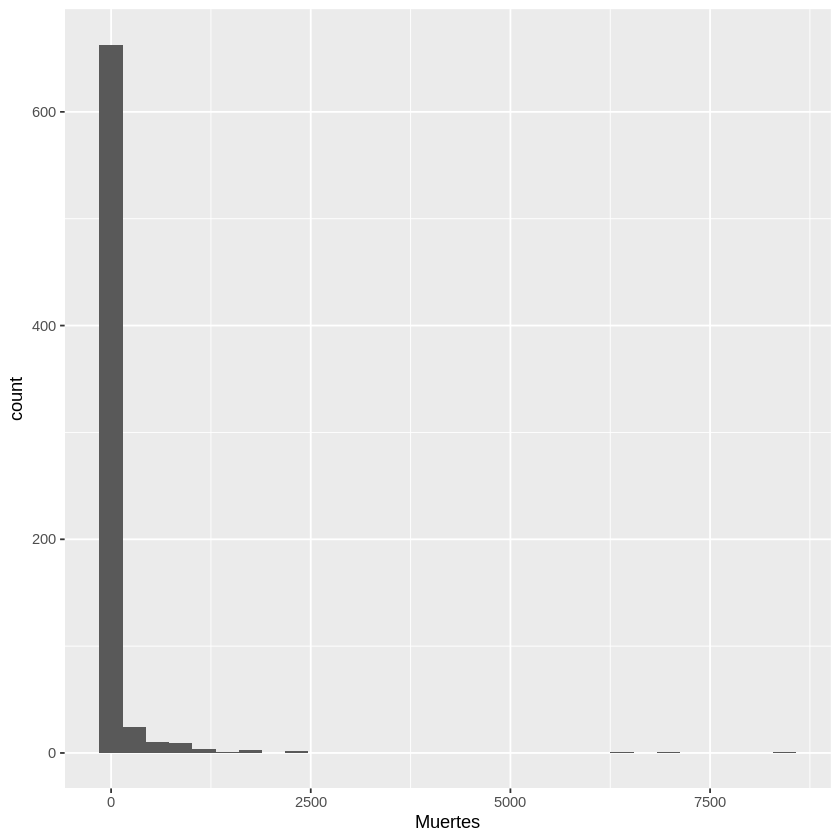

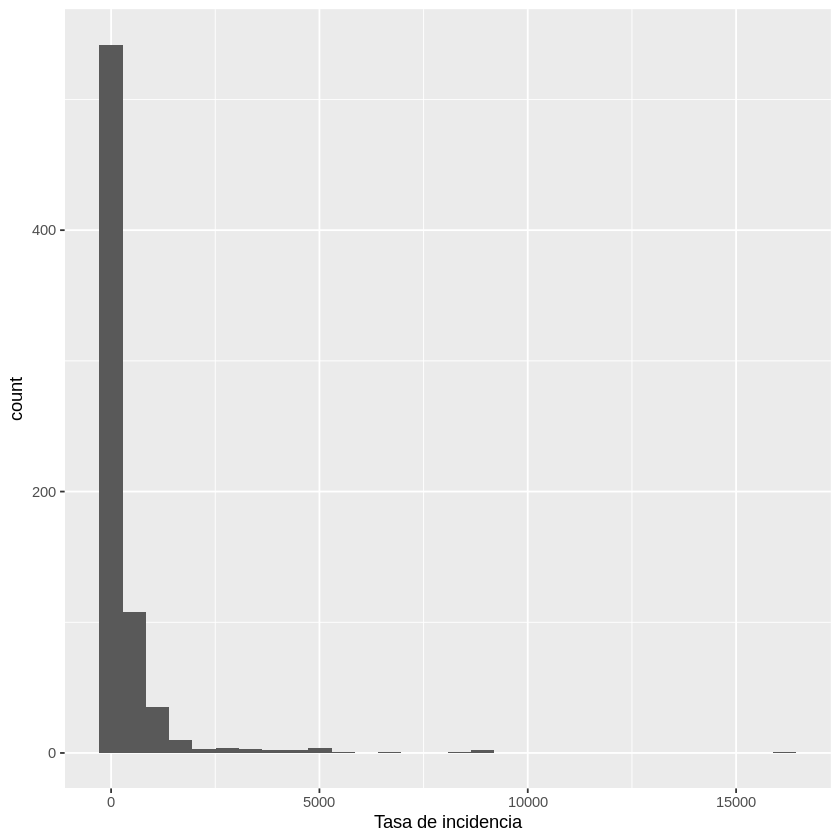

In [20]:
# Histogramas
ggplot(dengue_data, aes(x = deaths)) +
  geom_histogram(bins = 30) +
  labs(x = "Muertes")

ggplot(dengue_data, aes(x = incidence_rate_c)) +
  geom_histogram(bins = 30) +
  labs(x = "Tasa de incidencia")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 13 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”


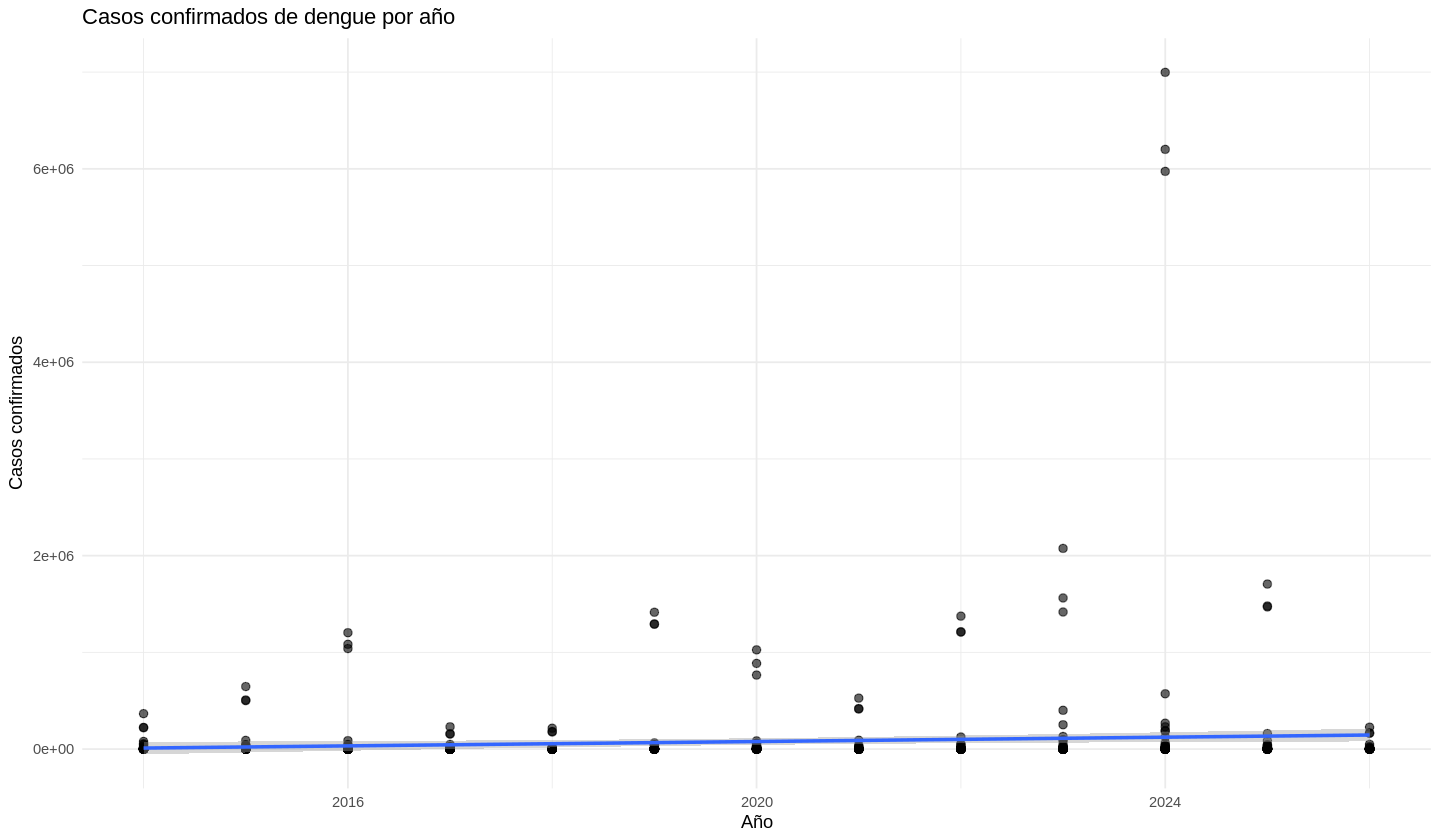

In [26]:
options(repr.plot.width = 12, repr.plot.height = 7)

ggplot(dengue_data, aes(x = year, y = confirmed)) +
  geom_point(size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Casos confirmados de dengue por año",
    x = "Año",
    y = "Casos confirmados"
  ) +
  theme_minimal()

In [27]:
# Tabla de casos de Dengue confirmados en 2024 por país

casos_2024_pais <- dengue_data %>%
  filter(year == 2024) %>%
  group_by(country_sp) %>%
  summarise(
    total_confirmados = sum(confirmed, na.rm = TRUE)
  ) %>%
  arrange(desc(total_confirmados))

casos_2024_pais

country_sp,total_confirmados
<chr>,<int>
Las Américas,6997321
Cono Sur,6200875
Brasil,5973340
Subregión Andina,571938
Perú,267377
Colombia,230369
Argentina,188410
Istmo Centroamericano y México,187445
México,125160


In [28]:
tabla_id_pais <- dengue_data %>%
  select(id, country_sp) %>%
  distinct() %>%
  arrange(id)

tabla_id_pais

id,country_sp
<int>,<chr>
1,Estados Unidos de América
1,Canadá
1,América del Norte
2,Honduras
2,Panamá
2,Costa Rica
2,Belice
2,El Salvador
2,Guatemala


En teoría, en la variable "country_sp" debería de ser solamente para paises, mientras de que la variable "country_or_subregion", debe de tener ambos datos. Es por esto que se opta por crear una nueva columna para ayudar en el análisis de datos llamada `tipo_registro`.

Por otro lado para facilitar los análisis se crearán listas para agrupar los elementos que serán interesantes para el análisis.





In [29]:
# Creación de región lista consolidada

regiones_consolidadas <- c(
  "Las Américas",
  "América del Norte",
  "Istmo Centroamericano y México",
  "Subregión Andina",
  "Cono Sur",
  "Caribe Latino",
  "Caribe No Latino"
)

In [30]:
# Creación de columna nueva "tipo de registro"

dengue_data <- dengue_data %>%
  mutate(
    tipo_registro = ifelse(
      country_sp %in% regiones_consolidadas,
      "Consolidado regional",
      "País / territorio"
    )
  )

In [31]:
# Revisón de la integración de la columna
table(dengue_data$tipo_registro)


Consolidado regional    País / territorio 
                  91                  628 

Esta Columna nos sirve como un filtro para realizar  análisis de tipo regional o por paises:
```
datos_regionales <- dengue_data %>%
  filter(tipo_registro == "Consolidado regional")
```

```
datos_paises <- dengue_data %>%
  filter(tipo_registro == "País / territorio")
```
A continuación se realizará el análisis de los casos de dengue confirmados a lo largo de los años pero a nivel regional


In [33]:
# creación del filtro para casos regionales
casos_regionales_anio <- dengue_data %>%
  filter(tipo_registro == "Consolidado regional") %>%
  group_by(year, country_sp) %>%
  summarise(
    total_confirmados = sum(confirmed, na.rm = TRUE),
    .groups = "drop"
  )

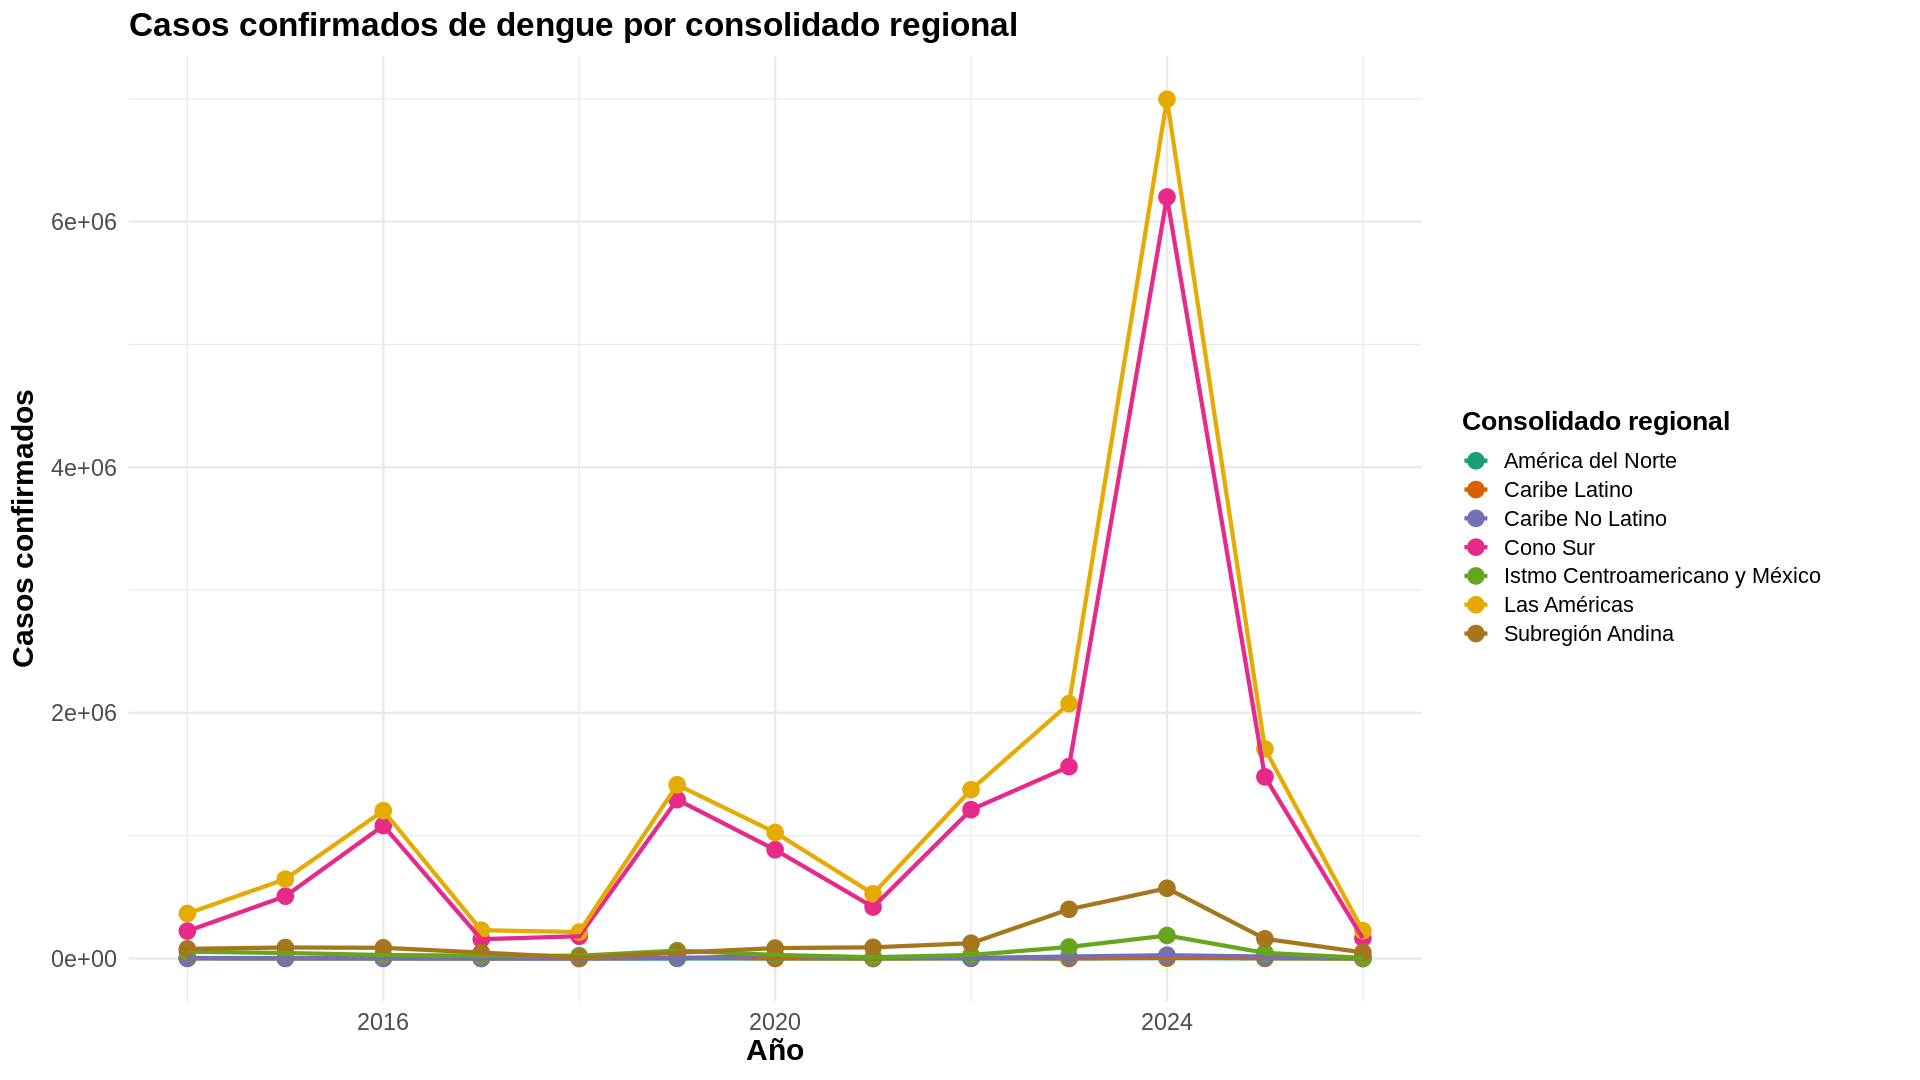

In [44]:
# Gráfico de dispersión para datos regionales y años sobre casos de dengue confirmados

library(ggplot2)

options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(casos_regionales_anio,
       aes(x = year, y = total_confirmados, color = country_sp)) +
  geom_point(size = 4) +
  geom_line(aes(group = country_sp), linewidth = 1.2) +
  labs(
    title = "Casos confirmados de dengue por consolidado regional",
    x = "Año",
    y = "Casos confirmados",
    color = "Consolidado regional"
  ) +
  scale_color_brewer(palette = "Dark2") +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title = element_text(size = 18, face = "bold"),
    axis.text = element_text(size = 14),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 13),
    legend.position = "right"
  )

In [45]:
# Revisión de países que se encuentran en la región de Cono Sur

paises_cono_sur <- dengue_data %>%
  filter(
    id == 4,
    tipo_registro == "País / territorio"
  ) %>%
  select(id, country_sp) %>%
  distinct() %>%
  arrange(country_sp)

paises_cono_sur

id,country_sp
<int>,<chr>
4,Argentina
4,Brasil
4,Chile
4,Paraguay
4,Uruguay


In [48]:
# Revisión de datos de casos confirmados de Dengue y países del Cono Sur
tabla_cono_sur_ancha <- dengue_data %>%
  filter(
    id == 4,
    tipo_registro == "País / territorio"
  ) %>%
  group_by(country_sp, year) %>%
  summarise(
    confirmed = sum(confirmed, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = year,
    values_from = confirmed,
    values_fill = 0
  ) %>%
  arrange(country_sp)

tabla_cono_sur_ancha

country_sp,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Argentina,490,1208,41211,254,1175,1720,58415,3972,841,130287,188410,8111,44
Brasil,220539,500972,1039147,156169,176814,1290861,765114,414154,1210760,1417218,5973340,1469805,164780
Chile,30,7,0,10,18,28,9,0,0,0,157,0,17
Paraguay,2601,5258,2556,616,3414,1161,62090,794,195,14936,37829,1374,197
Uruguay,0,0,0,0,0,0,4,2,20,48,1139,7,0
